In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

In [3]:
df = pd.read_excel("final_results.xlsx")

In [4]:
# List of columns that contain (IQR ...) strings
columns_to_clean = [
    'prompt_prefill_speed', 'generation_decoder_speed', 'prefill_latency', 
    'generation_latency', 'inference_latency', 'time_to_first_token', 
    'total_energy_consumption', 'energy_per_token'
]

# Iterate through columns to remove IQR and convert to float
for col in columns_to_clean:
    # Split the string by space and keep the first part (the numeric value)
    df[col] = df[col].astype(str).str.split(' ').str[0].astype(float)

In [5]:
# Clean up model names for better visualization

df_name_clean = df.copy()

df_name_clean['model_name'] = (
    df_name_clean['model_name']
    .astype(str)
    .str.replace('Q4_K_M', '', regex=False)
    .str.replace('IQ4_XS', '', regex=False)
    .str.replace('__', '_', regex=False)
    .str.replace('--', '-', regex=False)
    .str.strip('_- ')
)


In [6]:
df8 = df_name_clean.head(8)   # Q4_K_M
df16 = df_name_clean.tail(8)  # IQ4_XS

prefill_color = "#94A6F1"
generation_color = "#FFAA4F"

w = 0.2
x = np.arange(len(df8))  # assume same model order

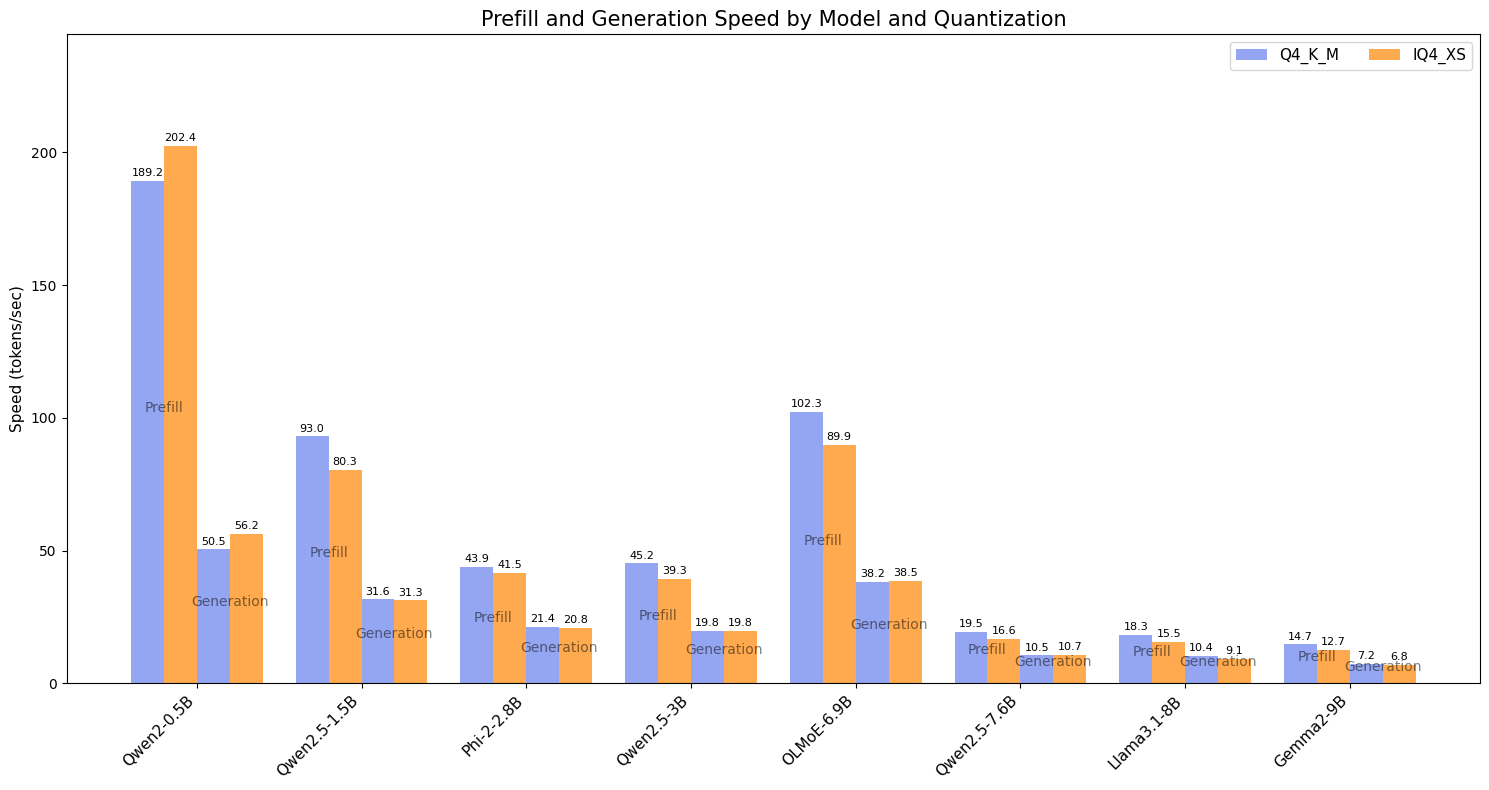

In [7]:

def label_bars(ax, bars):
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)

def label_group(ax, x_center, y_value, text):
    ax.text(
        x_center,
        y_value / 2,
        text,
        ha="center",
        va="bottom",
        fontsize=10,
        alpha=0.5
    )

# ---------------- Data ----------------
n = len(df8)
x = np.arange(n)
w = 0.2

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(15, 8))

# ---- Bars ----
b1 = ax.bar(
    x - 1.5*w,
    df8["prompt_prefill_speed"],
    w,
    label="Q4_K_M",
    color=prefill_color
)

b2 = ax.bar(
    x - 0.5*w,
    df16["prompt_prefill_speed"],
    w,
    label="IQ4_XS",
    color=generation_color
)

b3 = ax.bar(
    x + 0.5*w,
    df8["generation_decoder_speed"],
    w,
    color=prefill_color
)

b4 = ax.bar(
    x + 1.5*w,
    df16["generation_decoder_speed"],
    w,
    color=generation_color
)

# ---------------- Formatting ----------------
ax.set_xticks(x)
ax.set_xticklabels(df8["model_name"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Speed (tokens/sec)", fontsize=11)
ax.set_title("Prefill and Generation Speed by Model and Quantization", fontsize=15)

ax.legend(fontsize=11, ncol=2)

# ---------------- Bar Value Labels ----------------
for bars in [b1, b2, b3, b4]:
    label_bars(ax, bars)

# ---------------- Group Labels ----------------
for i in range(n):
    # Prefill group
    prefill_x = x[i] - w
    prefill_y = max(
        df8["prompt_prefill_speed"].iloc[i],
        df16["prompt_prefill_speed"].iloc[i]
    )
    label_group(ax, prefill_x, prefill_y, "Prefill")

    # Generation group
    generation_x = x[i] + w
    generation_y = max(
        df8["generation_decoder_speed"].iloc[i],
        df16["generation_decoder_speed"].iloc[i]
    )
    label_group(ax, generation_x, generation_y, "Generation")

# ---------------- Final Touch ----------------
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()


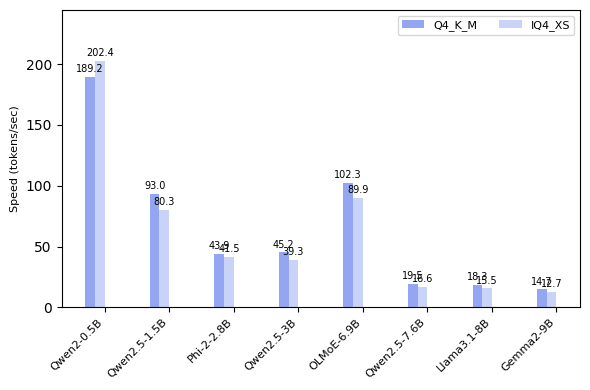

In [8]:
# ---------------- Data ----------------
n = len(df8)
x = np.arange(n)
w = 0.15

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(6, 4))

# ---- Bars ----
b1 = ax.bar(
    x - 1.5*w,
    df8["prompt_prefill_speed"],
    w,
    label="Q4_K_M",
    color=prefill_color
)

b2 = ax.bar(
    x - 0.5*w,
    df16["prompt_prefill_speed"],
    w,
    label="IQ4_XS",
    color=prefill_color,
    alpha=0.5
)

# ---------------- Formatting ----------------
ax.set_xticks(x)
ax.set_xticklabels(df8["model_name"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Speed (tokens/sec)", fontsize=8)

ax.bar_label(b1, fmt='%.1f', padding=2, fontsize=7)
ax.bar_label(b2, fmt='%.1f', padding=2, fontsize=7)

ax.legend(fontsize=8, ncol=2)

# ---------------- Final Touch ----------------
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()


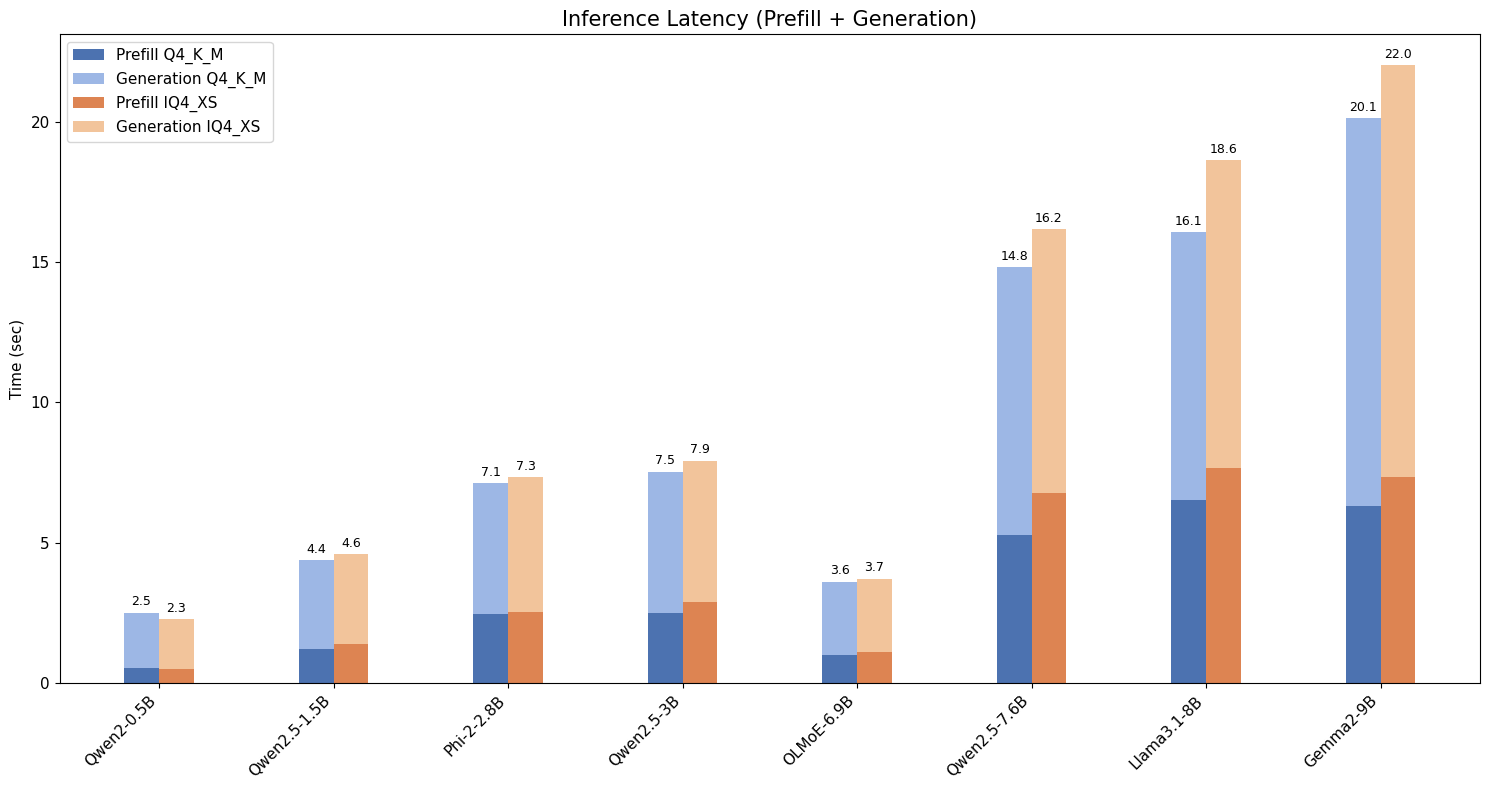

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def label_bars(ax, bars):
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

prefill_q4 = "#4C72B0"     # muted blue
gen_q4     = "#9DB7E5"     # lighter blue
prefill_iq = "#DD8452"     # warm orange
gen_iq     = "#F2C49B"     # light orange

# ---- Setup ----
x = np.arange(len(df8["model_name"]))
w = 0.2

fig, ax = plt.subplots(figsize=(15, 8))

# =======================
# Q4_K_M (df8)
# =======================
b1 = ax.bar(
    x - w/2,
    df8["prefill_latency"],
    w,
    label="Prefill Q4_K_M",
    color=prefill_q4
)

b2 = ax.bar(
    x - w/2,
    df8["generation_latency"],
    w,
    label="Generation Q4_K_M",
    bottom=df8["prefill_latency"],
    color=gen_q4,
)

# =======================
# IQ4_XS (df16)
# =======================
b3 = ax.bar(
    x + w/2,
    df16["prefill_latency"],
    w,
    label="Prefill IQ4_XS",
    color=prefill_iq,
)

b4 = ax.bar(
    x + w/2,
    df16["generation_latency"],
    w,
    label="Generation IQ4_XS",
    bottom=df16["prefill_latency"],
    color=gen_iq,
)

# ---- Formatting ----
ax.set_xticks(x)
ax.set_xticklabels(df8["model_name"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Time (sec)", fontsize=11)
ax.set_title("Inference Latency (Prefill + Generation)", fontsize=15)
ax.tick_params(axis="y", labelsize=11)
ax.legend(fontsize=11)

# ---- Optional: label only the top (total inference latency) ----
label_bars(ax, b2)
label_bars(ax, b4)


plt.tight_layout()
plt.show()


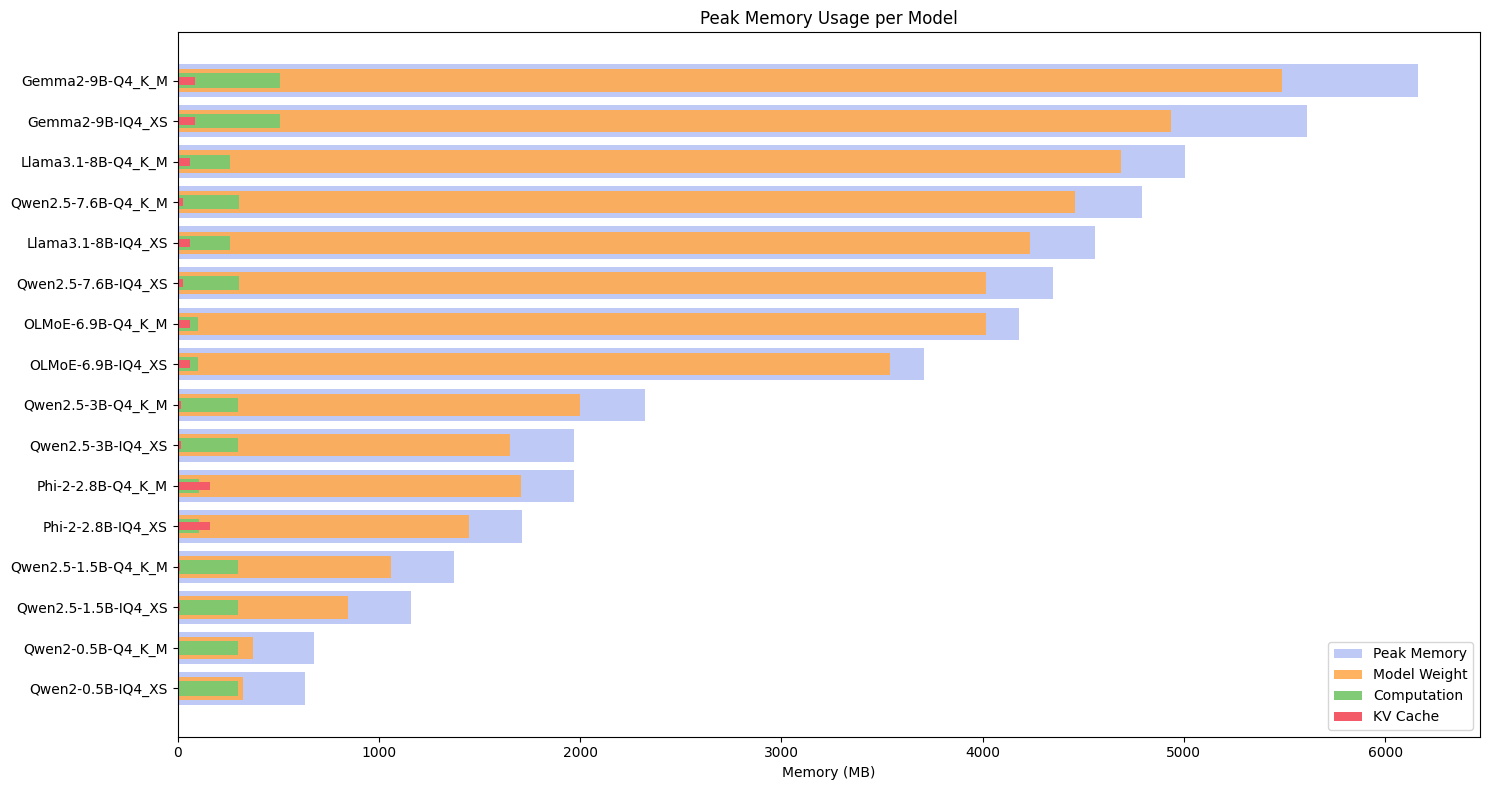

In [10]:
df_sorted_mem = df.sort_values('peak_memory', ascending=True)

plt.figure(figsize=(15, 8))

models = df_sorted_mem['model_name']
y_pos = np.arange(len(models))

# Heights (outer → inner)
h_peak = 0.8
h_weight = 0.55
h_compute = 0.35
h_kv = 0.2

# Peak Memory (outermost)
plt.barh(
    y_pos,
    df_sorted_mem['peak_memory'],
    height=h_peak,
    color="#94A6F1",
    alpha=0.6,
    label="Peak Memory"
)

# Model Weight
plt.barh(
    y_pos,
    df_sorted_mem['model_weight'],
    height=h_weight,
    color="#FFAA4F",
    alpha=0.9,
    label="Model Weight"
)

# Compute RAM
plt.barh(
    y_pos,
    df_sorted_mem['compute_RAM'],
    height=h_compute,
    color="#7BC96F",
    alpha=0.95,
    label="Computation"
)

# KV Cache
plt.barh(
    y_pos,
    df_sorted_mem['KV_cache'],
    height=h_kv,
    color="#F45B69",
    alpha=1.0,
    label="KV Cache"
)

plt.yticks(y_pos, models)
plt.xlabel("Memory (MB)")
plt.title("Peak Memory Usage per Model")
plt.legend()
plt.tight_layout()
plt.show()


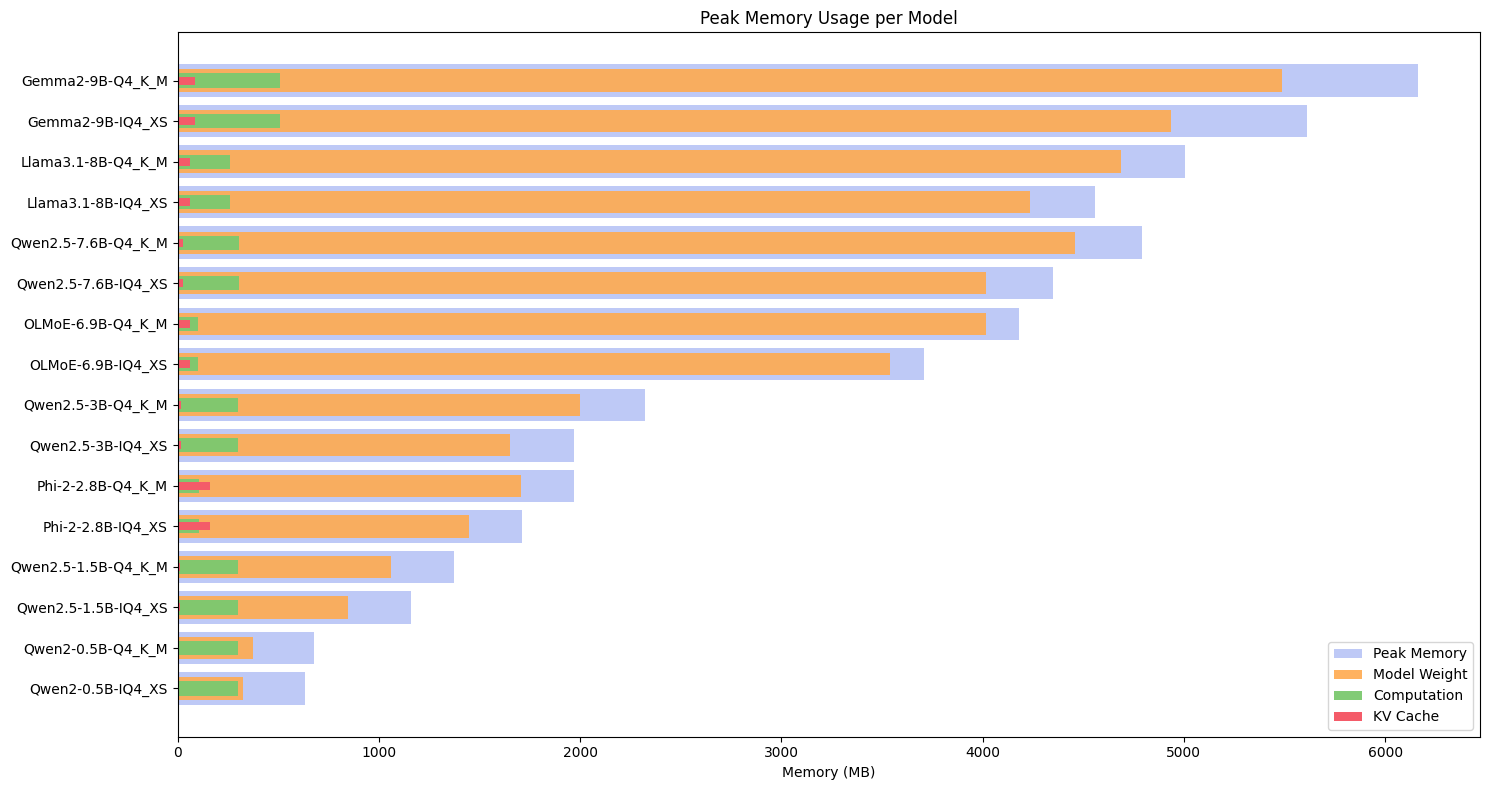

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Group-by-base-model, ordered high -> low
# -----------------------------

# Work on a copy
df2 = df.copy()

# 1) Split model name into base model + quant (assumes last "-" separates quant)
df2[['base_model', 'quant']] = df2['model_name'].str.rsplit('-', n=1, expand=True)

# 2) Optional: enforce a preferred quant order (only keep those present)
quant_order = [
    "Q4_K_M", "Q4_0",
    "Q5_K_M", "Q5_0",
    "Q6_K", "Q8_0",
    "IQ4_XS", "IQ4_S", "IQ4_M",
    "IQ3_XS", "IQ3_S",
    "IQ2_XS",
]
present_quants = set(df2['quant'])
quant_order_present = [q for q in quant_order if q in present_quants]

if quant_order_present:
    df2['quant'] = pd.Categorical(df2['quant'], categories=quant_order_present, ordered=True)
else:
    # fallback: keep as string (alphabetical) if none of the above matched
    df2['quant'] = df2['quant'].astype(str)

# 3) Rank base models by their maximum peak_memory (high -> low)
base_rank = (
    df2.groupby('base_model', as_index=False)['peak_memory']
       .max()
       .sort_values('peak_memory', ascending=False)['base_model']
       .tolist()
)
df2['base_model'] = pd.Categorical(df2['base_model'], categories=base_rank, ordered=True)

# 4) Sort:
#    - base_model by rank (already high->low via categories)
#    - quant in your preferred order
#    - within same base+quant, peak_memory high->low (usually irrelevant but stable)
df_sorted_mem = df2.sort_values(
    by=['base_model', 'quant', 'peak_memory'],
    ascending=[True, True, False]
).reset_index(drop=True)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(15, 8))

models = df_sorted_mem['model_name']
y_pos = np.arange(len(models))

# Heights (outer → inner)
h_peak = 0.8
h_weight = 0.55
h_compute = 0.35
h_kv = 0.2

# Peak Memory (outermost)
plt.barh(
    y_pos,
    df_sorted_mem['peak_memory'],
    height=h_peak,
    color="#94A6F1",
    alpha=0.6,
    label="Peak Memory"
)

# Model Weight
plt.barh(
    y_pos,
    df_sorted_mem['model_weight'],
    height=h_weight,
    color="#FFAA4F",
    alpha=0.9,
    label="Model Weight"
)

# Compute RAM
plt.barh(
    y_pos,
    df_sorted_mem['compute_RAM'],
    height=h_compute,
    color="#7BC96F",
    alpha=0.95,
    label="Computation"
)

# KV Cache
plt.barh(
    y_pos,
    df_sorted_mem['KV_cache'],
    height=h_kv,
    color="#F45B69",
    alpha=1.0,
    label="KV Cache"
)

plt.yticks(y_pos, models)
plt.xlabel("Memory (MB)")
plt.title("Peak Memory Usage per Model")
plt.legend()
plt.tight_layout()

# Put the biggest groups at the top (common for ranked bar charts)
plt.gca().invert_yaxis()

plt.show()


In [12]:
# For keeping same color of model names

df_model_name = df[['model_name']].copy()

df_model_name['model_name'] = (
    df_model_name['model_name']
    .astype(str)
    .str.replace('Q4_K_M', '', regex=False)
    .str.replace('IQ4_XS', '', regex=False)
    .str.replace('__', '_', regex=False)
    .str.replace('--', '-', regex=False)
    .str.strip('_- ')
)


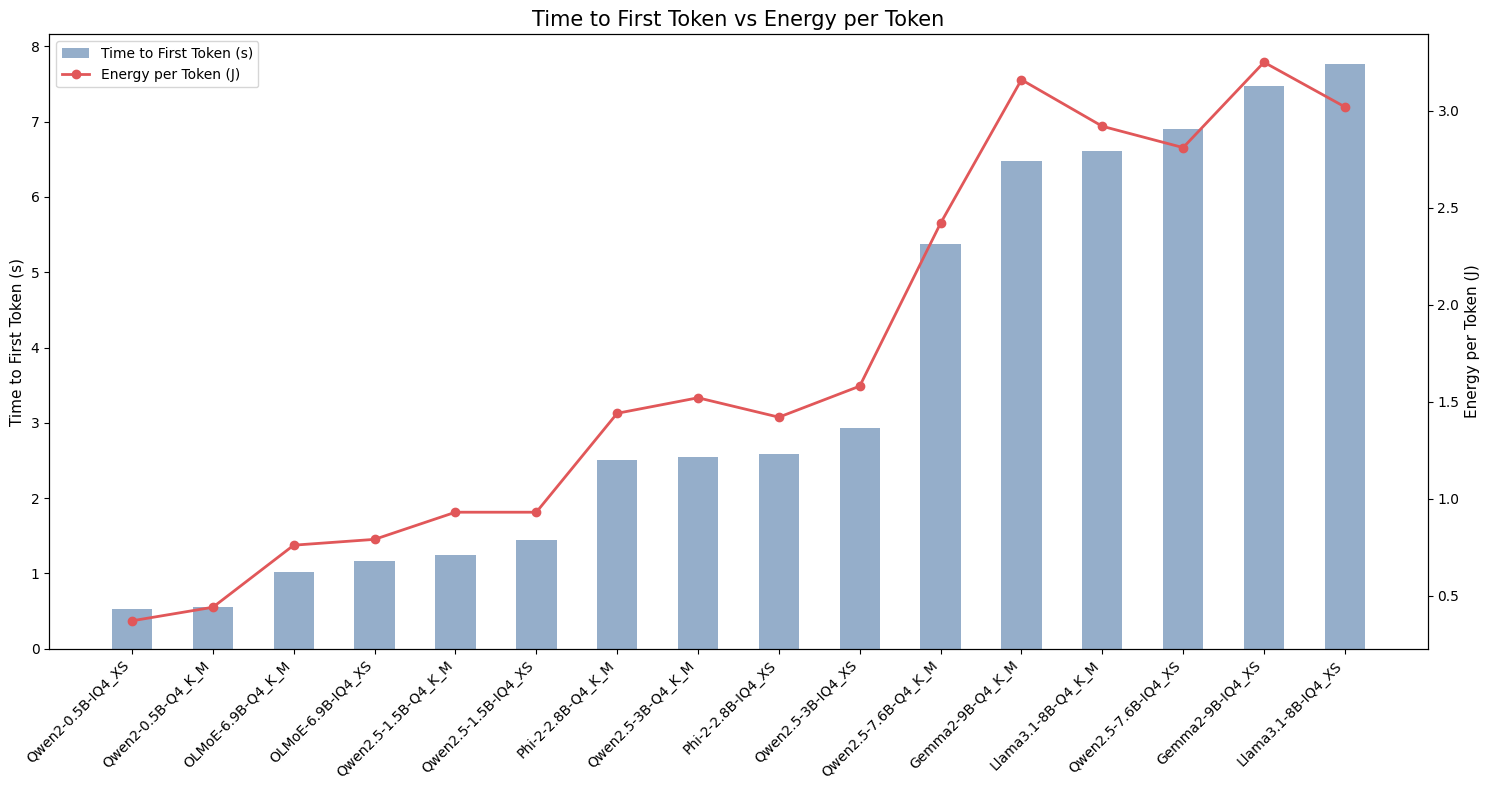

In [13]:
# Sort by Time to First Token to create a logical flow
df_sorted = df.sort_values('time_to_first_token', ascending=True)

# Create the figure and primary axis
fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot Time to First Token as Bars (Primary Axis)
bars = ax1.bar(df_sorted['model_name'], df_sorted['time_to_first_token'], color='#4e79a7', alpha=0.6, width=0.5, label='Time to First Token (s)')
ax1.set_ylabel('Time to First Token (s)', fontsize=11)
ax1.tick_params(axis='y')
plt.xticks(rotation=45, ha='right')

# Create secondary axis for Energy per Token
ax2 = ax1.twinx()
line = ax2.plot(df_sorted['model_name'], df_sorted['energy_per_token'], color='#e15759', marker='o', linewidth=2, label='Energy per Token (J)')
ax2.set_ylabel('Energy per Token (J)', fontsize=11)
ax2.tick_params(axis='y')

# Add title
plt.title('Time to First Token vs Energy per Token', fontsize=15)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')


plt.grid(False)
plt.tight_layout()
plt.show()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


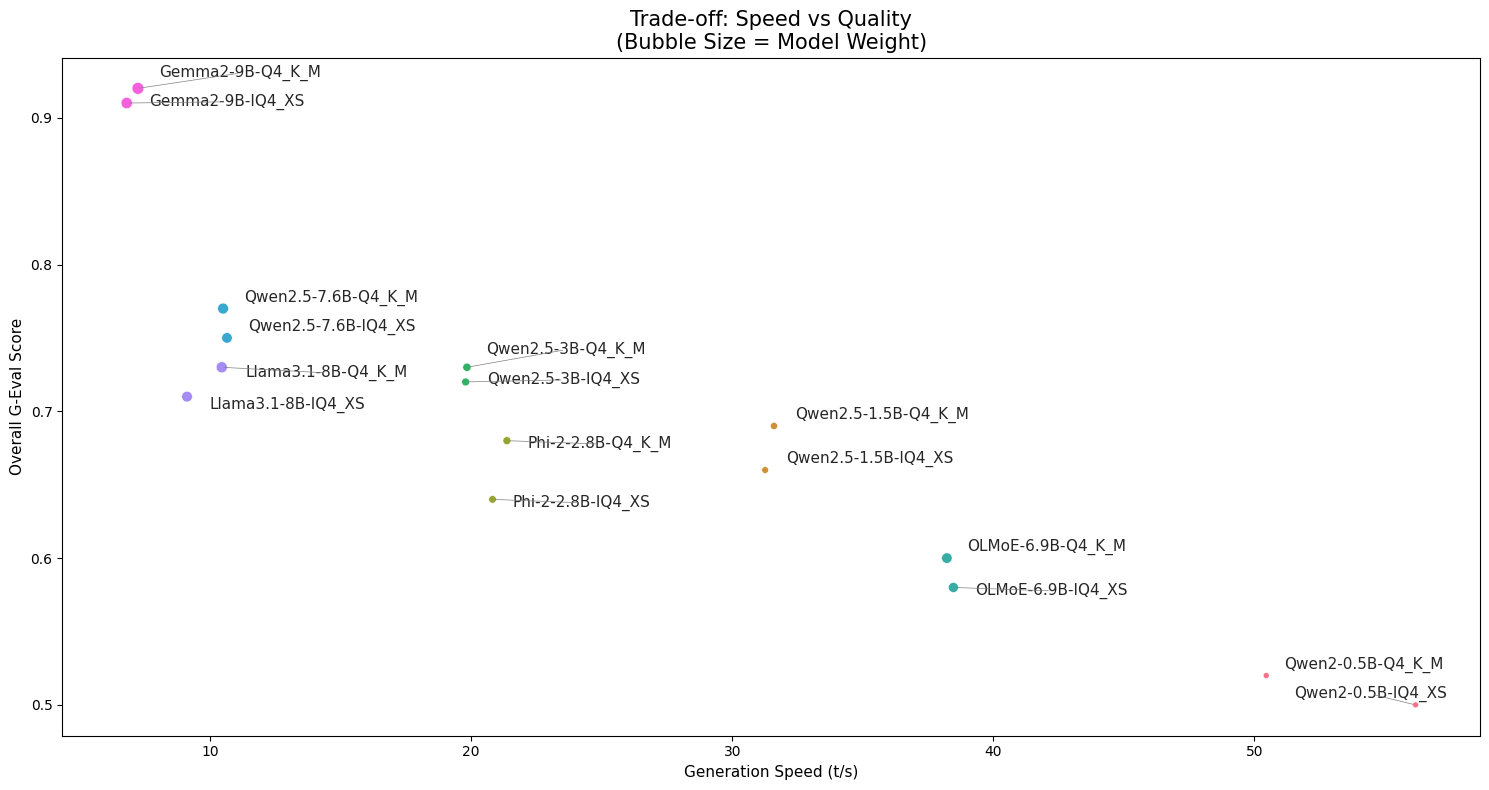

In [14]:

# Set the visual style
#sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(15, 8))
ax = sns.scatterplot(
    data=df,
    x='generation_decoder_speed',
    y='Overall_G-Eval',
    hue=df_model_name['model_name'],
    size='model_weight',
    palette='husl',
    s=80,
    legend=False
)

# Titles and labels
plt.title('Trade-off: Speed vs Quality\n(Bubble Size = Model Weight)', fontsize=15)
plt.xlabel('Generation Speed (t/s)', fontsize=11)
plt.ylabel('Overall G-Eval Score', fontsize=11)

# Create text objects
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row['generation_decoder_speed'],
            row['Overall_G-Eval'],
            row['model_name'],
            fontsize=11,
            alpha=0.85
        )
    )

# Automatically adjust label positions
adjust_text(
    texts,
    ax=ax,
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle="-", lw=0.5, color="gray")
)

plt.grid(False)
plt.tight_layout()
plt.show()

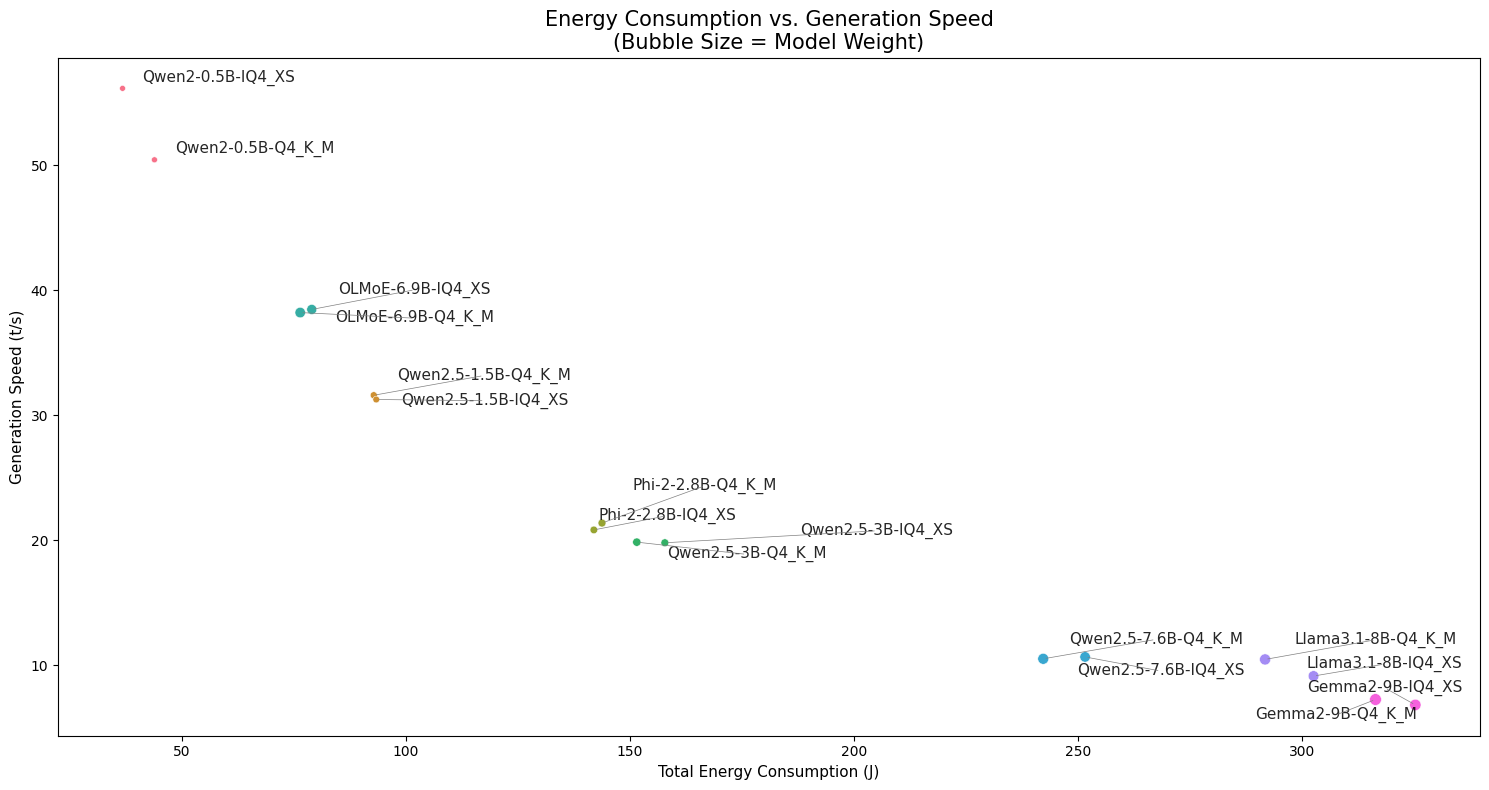

In [15]:

# Set the visual style
#sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(15, 8))
ax = sns.scatterplot(
    data=df,
    x='total_energy_consumption',
    y='generation_decoder_speed',
    hue=df_model_name['model_name'],
    size='model_weight',
    palette='husl',
    s=80,
    legend=False
)

# Titles and labels
plt.title('Energy Consumption vs. Generation Speed\n(Bubble Size = Model Weight)', fontsize=15)
plt.xlabel('Total Energy Consumption (J)', fontsize=11)
plt.ylabel('Generation Speed (t/s)', fontsize=11)

# Create text objects
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row['total_energy_consumption'],
            row['generation_decoder_speed'],
            row['model_name'],
            fontsize=11,
            alpha=0.85
        )
    )

# Automatically adjust label positions
adjust_text(
    texts,
    ax=ax,
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle="-", lw=0.5, color="gray")
)

plt.grid(False)
plt.tight_layout()
plt.show()


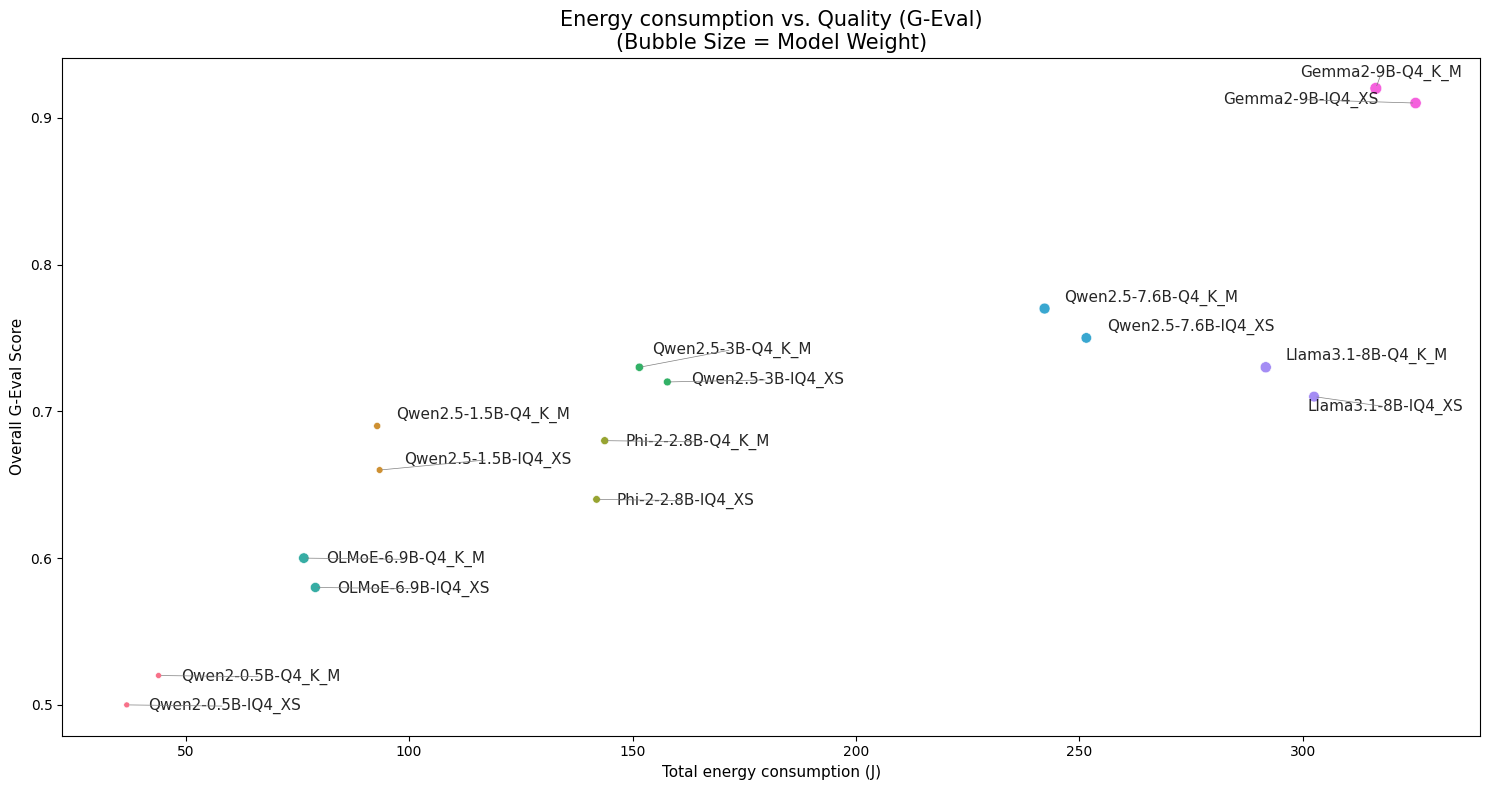

In [16]:

# Create the scatter plot
plt.figure(figsize=(15, 8))
ax = sns.scatterplot(
    data=df,
    x='total_energy_consumption',
    y='Overall_G-Eval',
    hue=df_model_name['model_name'],
    size='model_weight',
    palette='husl',
    s=80,
    legend=False
)

# Titles and labels
plt.title('Energy consumption vs. Quality (G-Eval)\n(Bubble Size = Model Weight)', fontsize=15)
plt.xlabel('Total energy consumption (J)', fontsize=11)
plt.ylabel('Overall G-Eval Score', fontsize=11)

# Create text objects
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row['total_energy_consumption'],
            row['Overall_G-Eval'],
            row['model_name'],
            fontsize=11,
            alpha=0.85
        )
    )

# Automatically adjust label positions
adjust_text(
    texts,
    ax=ax,
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle="-", lw=0.5, color="gray")
)

plt.grid(False)
plt.tight_layout()
plt.show()


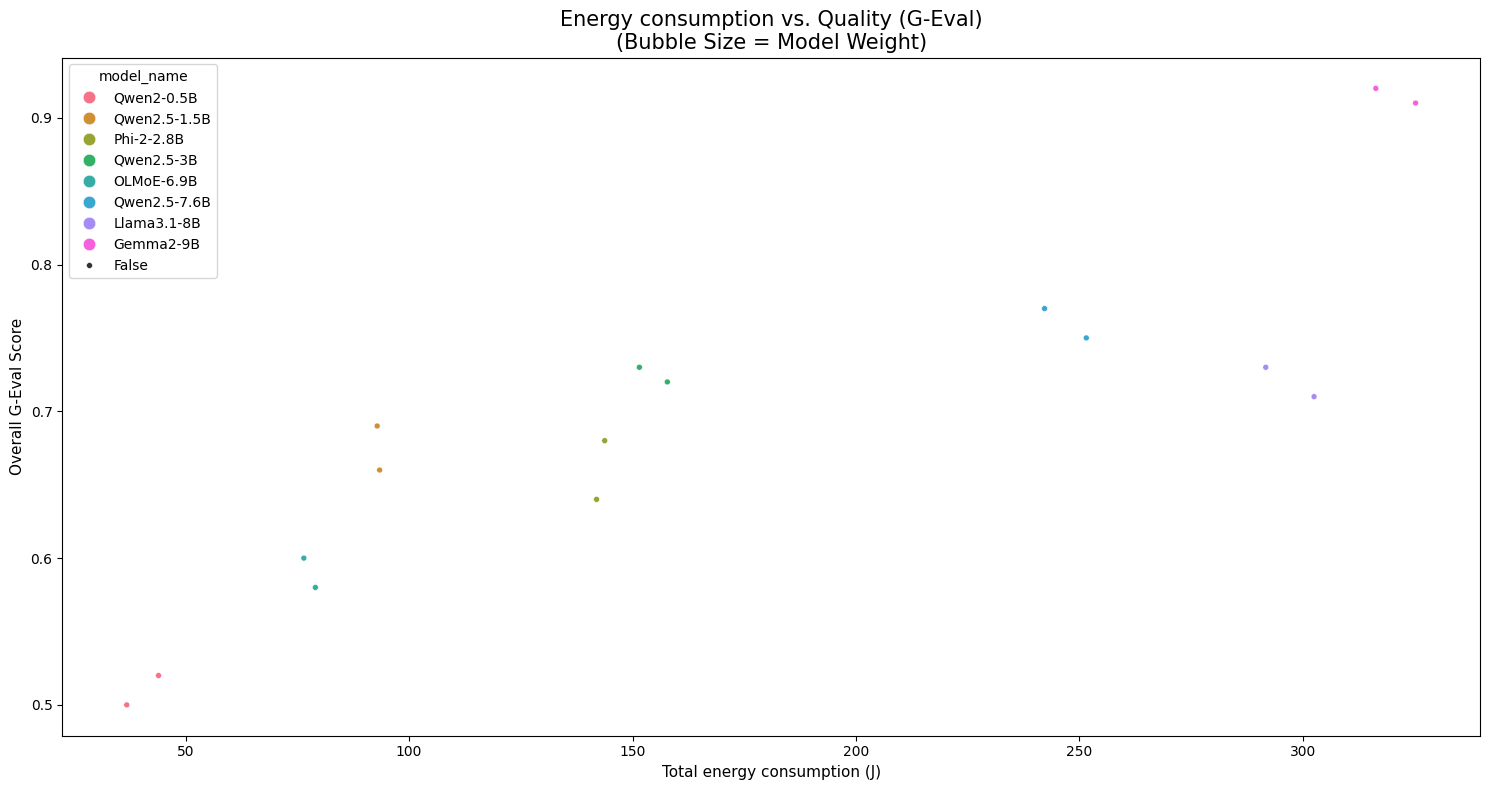

In [21]:

# Create the scatter plot
plt.figure(figsize=(15, 8))
ax = sns.scatterplot(
    data=df,
    x='total_energy_consumption',
    y='Overall_G-Eval',
    hue=df_model_name['model_name'],
    size=False,
    palette='husl',
    s=80,
    legend=True
)

# Titles and labels
plt.title('Energy consumption vs. Quality (G-Eval)\n(Bubble Size = Model Weight)', fontsize=15)
plt.xlabel('Total energy consumption (J)', fontsize=11)
plt.ylabel('Overall G-Eval Score', fontsize=11)


plt.grid(False)
plt.tight_layout()
plt.show()


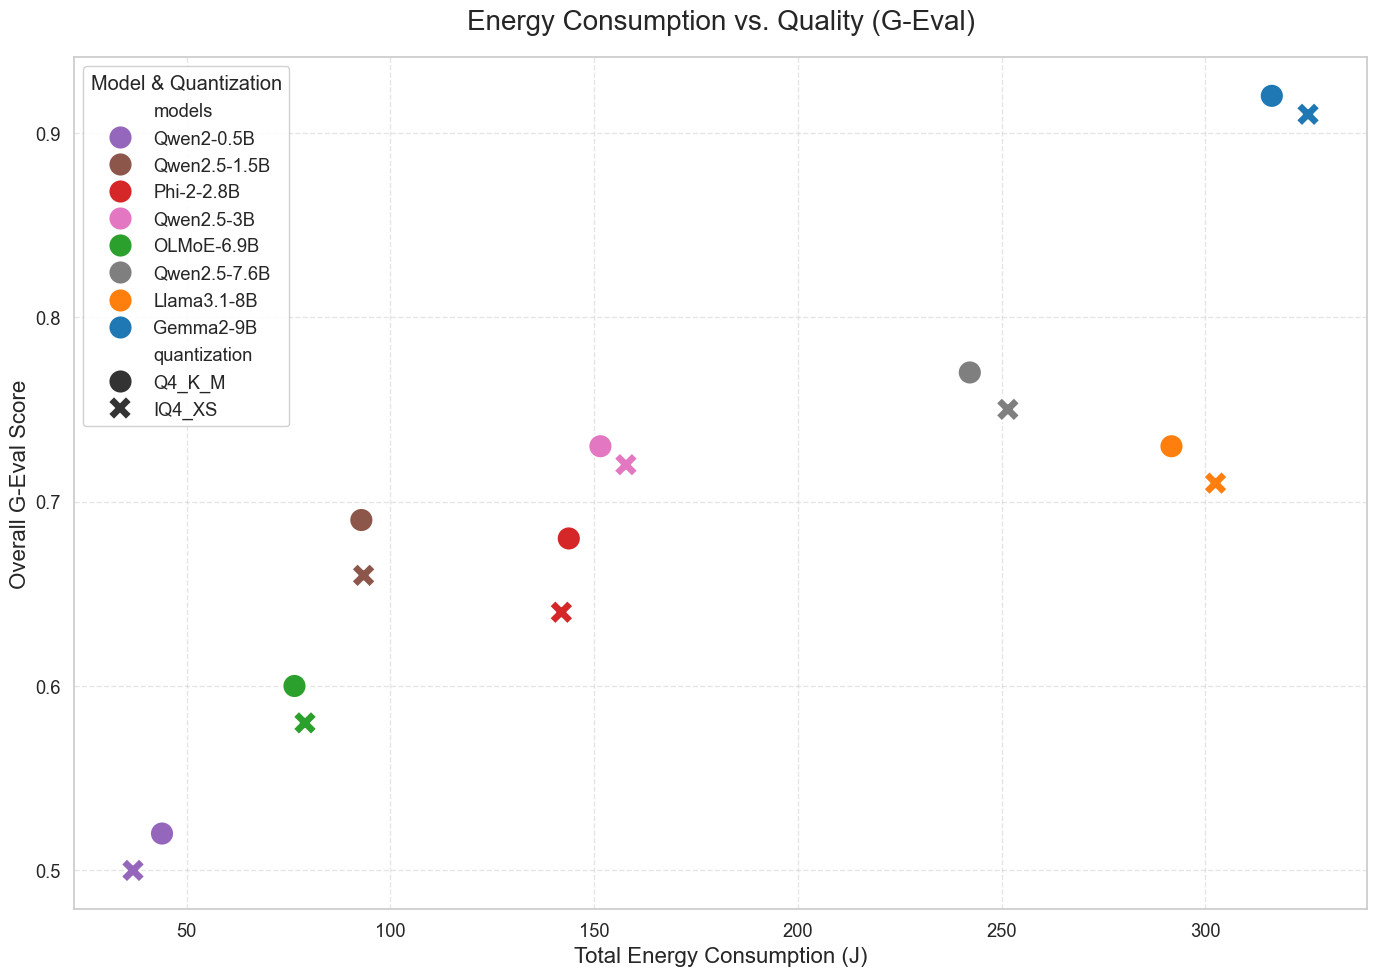

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Load the data
dft = pd.read_excel('final_results.xlsx')

# 2. Data Cleaning & Feature Extraction
# Extract numeric value from 'total_energy_consumption' (e.g., "43.95 (IQR...)" -> 43.95)
dft['total_energy_consumption_val'] = dft['total_energy_consumption'].astype(str).str.split().str[0].astype(float)

# Function to split 'model_name' into 'Base Model' and 'Quantization'
def extract_model_quant(name):
    parts = name.split('-')
    quant = parts[-1]               # The last part is quantization (e.g., Q4_K_M)
    base = '-'.join(parts[:-1])     # Everything else is the base model name
    return pd.Series([base, quant])

dft[['models', 'quantization']] = dft['model_name'].apply(extract_model_quant)

# 3. Setup the Plot
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Define a color palette for the models
unique_models = sorted(dft['models'].unique())
palette = sns.color_palette("tab10", len(unique_models))
color_map = dict(zip(unique_models, palette))

# 4. Create Scatter Plot
ax = sns.scatterplot(
    data=dft,
    x='total_energy_consumption_val',
    y='Overall_G-Eval',
    hue='models',      # Different Color = Different Model
    style='quantization',  # Different Shape = Different Quantization
    s=300,                 # Large marker size
    palette=color_map,
    markers=True,
    alpha=1.0,
    zorder=3
)

# 5. Draw "Shaded Polygons" (Connecting Lines)
# Loop through each model to draw a line connecting its quantization points
for model in unique_models:
    model_data = df[df['model_name'] == model]
    if len(model_data) > 1:
        model_data = model_data.sort_values('total_energy_consumption_val')
        
        x = model_data['total_energy_consumption_val'].values
        y = model_data['Overall_G-Eval'].values
        color = color_map[model]
        
        # Draw a thick transparent line to simulate the shaded polygon area
        plt.plot(x, y, color=color, linewidth=20, alpha=0.2, zorder=1)
        # Draw a solid thin line for connectivity
        plt.plot(x, y, color=color, linewidth=2, alpha=0.6, zorder=2)

# 6. Formatting
plt.title('Energy Consumption vs. Quality (G-Eval)', fontsize=20, pad=20)
plt.xlabel('Total Energy Consumption (J)', fontsize=16)
plt.ylabel('Overall G-Eval Score', fontsize=16)

# Move legend outside the plot
plt.legend(
    loc='upper left',          # Position INSIDE the axes
    title="Model & Quantization",
    frameon=True,               # Show legend box
    framealpha=0.9              # Slight transparency so data is still visible
)


plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Show
plt.savefig('scatter_plot_quantization_final.png', dpi=300, bbox_inches='tight')
plt.show()

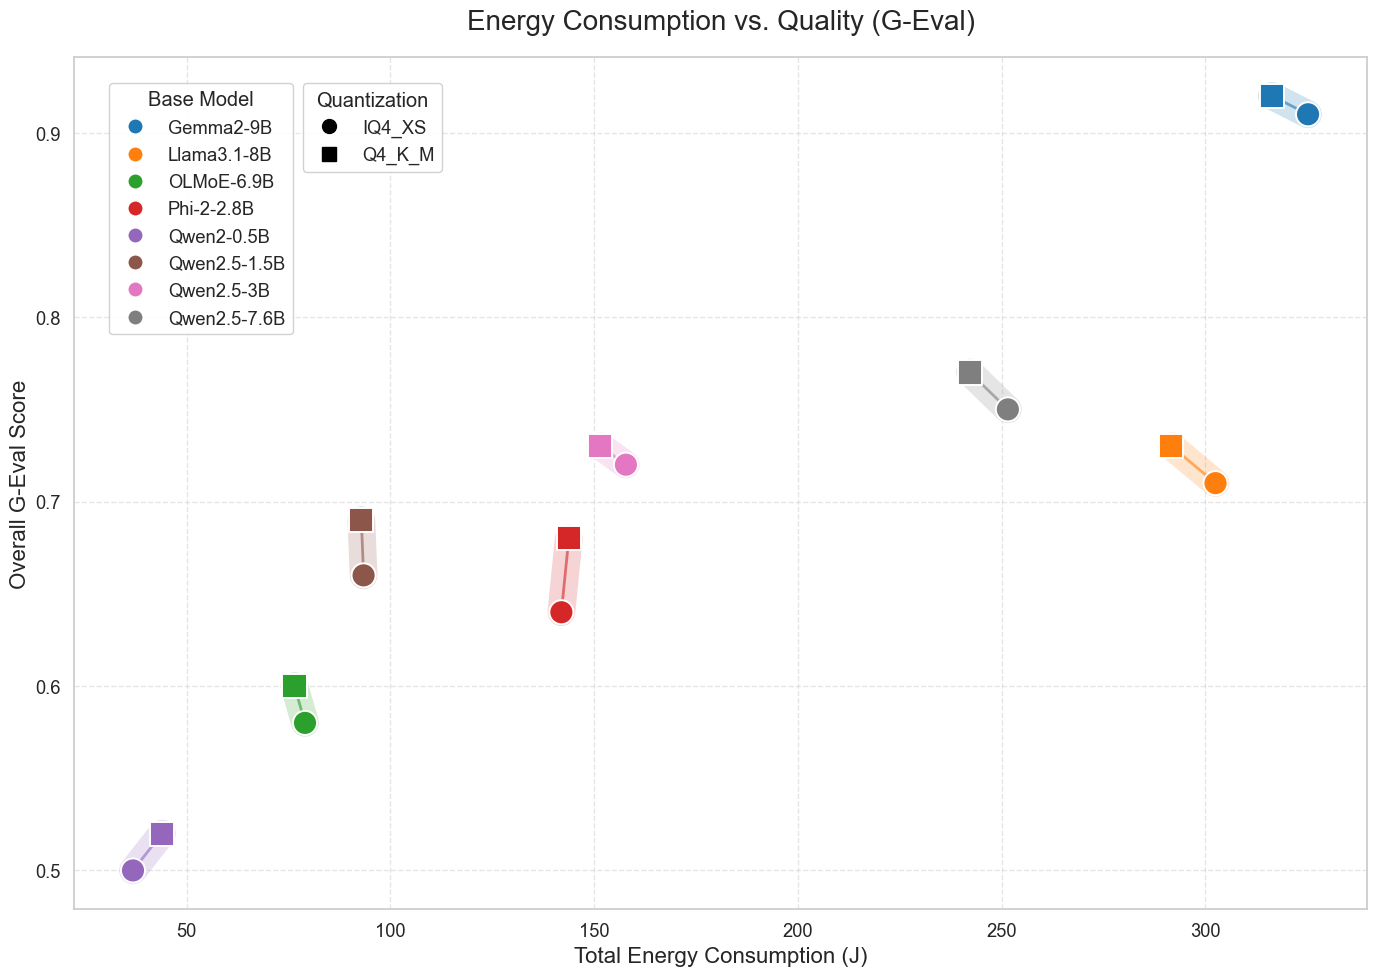

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# 1. Load the data
dft = pd.read_excel("final_results.xlsx")

# 2. Data Cleaning & Feature Extraction
# Extract numeric value from 'total_energy_consumption' (e.g., "43.95 (IQR...)" -> 43.95)
dft["total_energy_consumption_val"] = (
    dft["total_energy_consumption"].astype(str).str.split().str[0].astype(float)
)

# Function to split 'model_name' into 'Base Model' and 'Quantization'
def extract_model_quant(name: str):
    parts = str(name).split("-")
    quant = parts[-1]           # last part is quantization (e.g., Q4_K_M)
    base = "-".join(parts[:-1]) # rest is base model name
    return pd.Series([base, quant])

dft[["base_model", "quantization"]] = dft["model_name"].apply(extract_model_quant)

# 3. Setup the Plot
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Define color palette for base models
unique_models = sorted(dft["base_model"].unique())
palette = sns.color_palette("tab10", len(unique_models))
color_map = dict(zip(unique_models, palette))

# Define marker shapes for quantization levels (explicit & stable)
quant_levels = sorted(dft["quantization"].unique())
marker_styles = ["o", "s", "D", "^", "v", "P", "X", "*", "<", ">", "h", "H"]
quant_marker_map = dict(zip(quant_levels, marker_styles[: len(quant_levels)]))

# 4. Create Scatter Plot (we'll create our own legends)
ax = sns.scatterplot(
    data=dft,
    x="total_energy_consumption_val",
    y="Overall_G-Eval",
    hue="base_model",           # color encodes model
    style="quantization",       # marker encodes quantization
    palette=color_map,
    markers=quant_marker_map,   # explicit mapping
    s=300,
    alpha=1.0,
    zorder=3,
    legend="full",
)

# Remove Seaborn's combined legend (we'll add two separate ones)
if ax.legend_ is not None:
    ax.legend_.remove()

# 5. Draw "Shaded Polygons" (Connecting Lines) per base model
for model in unique_models:
    model_data = dft[dft["base_model"] == model].copy()
    if len(model_data) > 1:
        model_data = model_data.sort_values("total_energy_consumption_val")

        x = model_data["total_energy_consumption_val"].values
        y = model_data["Overall_G-Eval"].values
        color = color_map[model]

        # Thick transparent line (shaded look)
        plt.plot(x, y, color=color, linewidth=20, alpha=0.2, zorder=1)
        # Thin connectivity line
        plt.plot(x, y, color=color, linewidth=2, alpha=0.6, zorder=2)

# 6. Formatting
plt.title("Energy Consumption vs. Quality (G-Eval)", fontsize=20, pad=20)
plt.xlabel("Total Energy Consumption (J)", fontsize=16)
plt.ylabel("Overall G-Eval Score", fontsize=16)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# --- Split legends inside the plot ---

# Legend 1: Base Model (colors)
model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        label=m,
        markerfacecolor=color_map[m],
        markeredgecolor="none",
        markersize=10,
    )
    for m in unique_models
]
legend1 = ax.legend(
    handles=model_handles,
    title="Base Model",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),   # inside axes
    frameon=True,
    framealpha=0.9,
)

ax.add_artist(legend1)

# Legend 2: Quantization (shapes)
quant_handles = [
    Line2D(
        [0], [0],
        marker=quant_marker_map[q],
        linestyle="None",
        label=q,
        color="black",
        markerfacecolor="black",
        markersize=10,
    )
    for q in quant_levels
]
ax.legend(
    handles=quant_handles,
    title="Quantization",
    loc="upper left",
    bbox_to_anchor=(0.17, 0.98),   # inside axes
    frameon=True,
    framealpha=0.9,
)

plt.tight_layout()

plt.show()


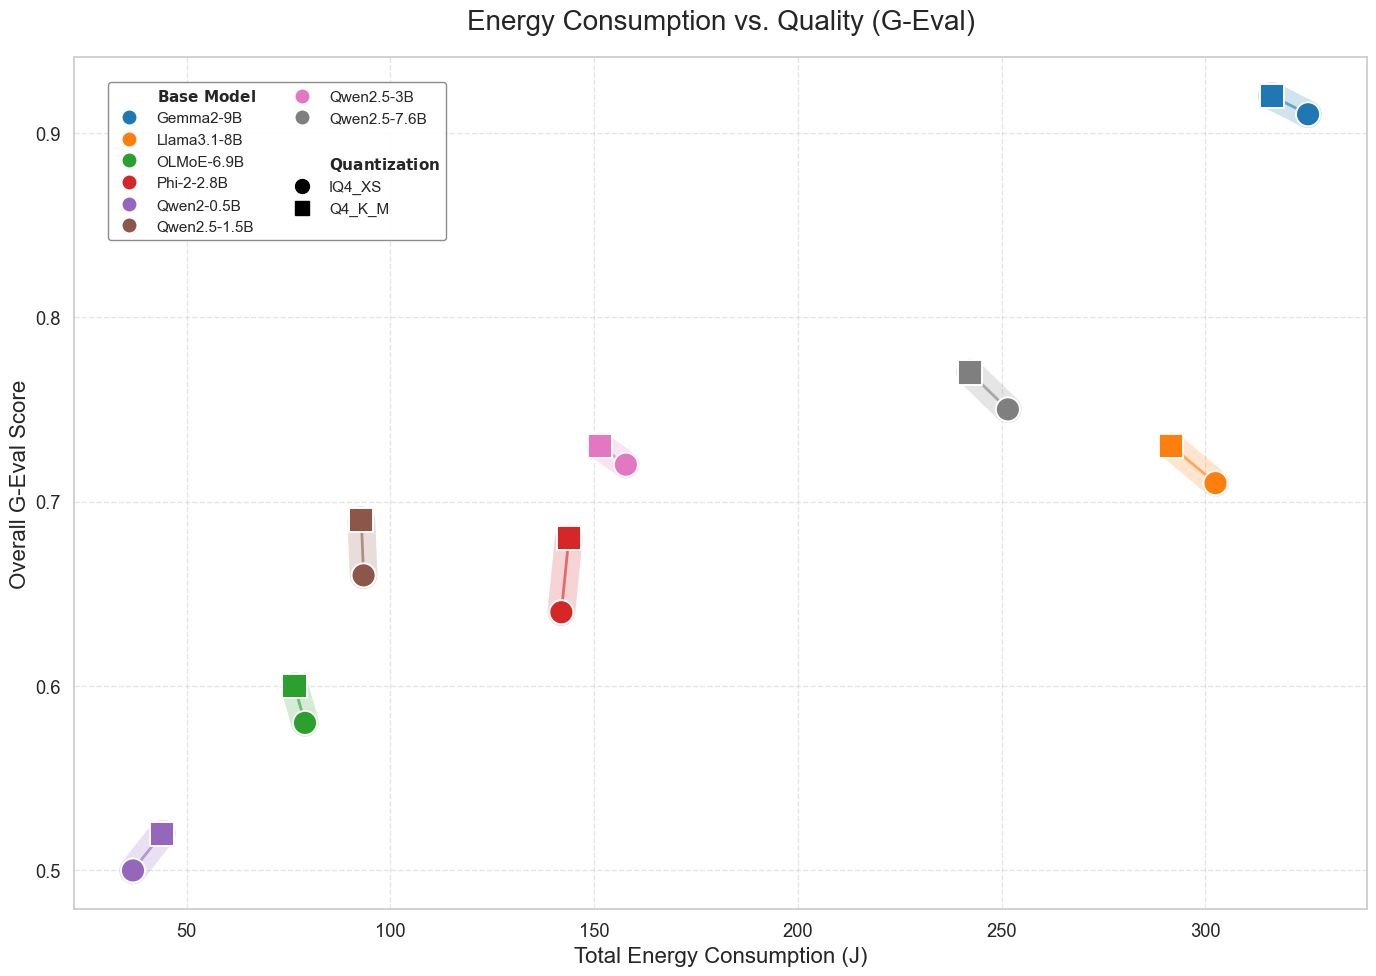

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# 1. Load the data
# Ensure 'final_results.xlsx' is in your working directory
dft = pd.read_excel("final_results.xlsx")

# 2. Data Cleaning & Feature Extraction
# Extract numeric value from 'total_energy_consumption'
dft["total_energy_consumption_val"] = (
    dft["total_energy_consumption"].astype(str).str.split().str[0].astype(float)
)

# Function to split 'model_name' into 'Base Model' and 'Quantization'
def extract_model_quant(name: str):
    parts = str(name).split("-")
    quant = parts[-1]           # last part is quantization (e.g., Q4_K_M)
    base = "-".join(parts[:-1]) # rest is base model name
    return pd.Series([base, quant])

dft[["base_model", "quantization"]] = dft["model_name"].apply(extract_model_quant)

# 3. Setup the Plot
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Define color palette for base models
unique_models = sorted(dft["base_model"].unique())
palette = sns.color_palette("tab10", len(unique_models))
color_map = dict(zip(unique_models, palette))

# Define marker shapes for quantization levels (explicit & stable)
quant_levels = sorted(dft["quantization"].unique())
marker_styles = ["o", "s", "D", "^", "v", "P", "X", "*", "<", ">", "h", "H"]
quant_marker_map = dict(zip(quant_levels, marker_styles[: len(quant_levels)]))

# 4. Create Scatter Plot
# Note: We set legend=False here because we will build a custom one
ax = sns.scatterplot(
    data=dft,
    x="total_energy_consumption_val",
    y="Overall_G-Eval",
    hue="base_model",
    style="quantization",
    palette=color_map,
    markers=quant_marker_map,
    s=300,
    alpha=1.0,
    zorder=3,
    legend=False, 
)

# 5. Draw "Shaded Polygons" (Connecting Lines) per base model
for model in unique_models:
    model_data = dft[dft["base_model"] == model].copy()
    if len(model_data) > 1:
        model_data = model_data.sort_values("total_energy_consumption_val")

        x = model_data["total_energy_consumption_val"].values
        y = model_data["Overall_G-Eval"].values
        color = color_map[model]

        # Thick transparent line (shaded look)
        plt.plot(x, y, color=color, linewidth=20, alpha=0.2, zorder=1)
        # Thin connectivity line
        plt.plot(x, y, color=color, linewidth=2, alpha=0.6, zorder=2)

# 6. Formatting
plt.title("Energy Consumption vs. Quality (G-Eval)", fontsize=20, pad=20)
plt.xlabel("Total Energy Consumption (J)", fontsize=16)
plt.ylabel("Overall G-Eval Score", fontsize=16)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# --- Custom Unified Legend ---

# Create "Header" handles (invisible points with bold text)
# We use LaTeX syntax r"$\bf{Text}$" to make the headers bold
header_models = Line2D([], [], color="none", label=r"$\bf{Base\ Model}$")
header_quants = Line2D([], [], color="none", label=r"$\bf{Quantization}$")
blank_space = Line2D([], [], color="none", label="") # Adds a small gap

# Create handles for Base Models (Colors)
model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        label=m,
        markerfacecolor=color_map[m],
        markeredgecolor="none",
        markersize=10,
    )
    for m in unique_models
]

# Create handles for Quantization (Shapes)
quant_handles = [
    Line2D(
        [0], [0],
        marker=quant_marker_map[q],
        linestyle="None",
        label=q,
        color="black",
        markerfacecolor="black",
        markersize=10,
    )
    for q in quant_levels
]

# Combine all handles into one list in the desired order
final_handles = (
    [header_models] + 
    model_handles + 
    [blank_space] + 
    [header_quants] + 
    quant_handles
)

# Add the single legend to the plot
ax.legend(
    handles=final_handles,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98), # Fine-tune position inside the plot
    frameon=True,
    framealpha=0.9,
    edgecolor="gray",
    fontsize=11,
    ncols = 2
)

plt.tight_layout()
plt.show()